# Part 3: Churn Prediction Model & Model Card
D2C Customer Churn Capstone


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import json, pickle, os, warnings
import os
os.makedirs('data', exist_ok=True)
os.makedirs('charts', exist_ok=True)
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, roc_curve,
    precision_recall_curve, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
os.makedirs('charts', exist_ok=True)

SNAPSHOT = pd.Timestamp('2025-09-30')

## 1. Load Modeling Snapshot

In [3]:
from google.colab import files
uploaded = files.upload()

Saving churn_labels.csv to churn_labels.csv
Saving customers.csv to customers.csv
Saving intervention_history.csv to intervention_history.csv
Saving orders.csv to orders.csv
Saving rfm_modeling_snapshot.csv to rfm_modeling_snapshot.csv
Saving support_tickets.csv to support_tickets.csv
Saving web_events_snapshot.csv to web_events_snapshot.csv


In [4]:
import shutil
for filename in uploaded.keys():
    shutil.move(filename, f'data/{filename}')
print('Done')

Done


In [5]:
rfm = pd.read_csv('data/rfm_modeling_snapshot.csv')
print('Shape:', rfm.shape)
print('Split counts:', rfm['split'].value_counts().to_dict())
print('Churn rate:', rfm['churn_next_60d'].mean().round(3))
print('Nulls:', rfm.isna().sum()[rfm.isna().sum()>0].to_dict())

Shape: (2400, 29)
Split counts: {'train': 1728, 'validation': 336, 'test': 336}
Churn rate: 0.47
Nulls: {'loyalty_tier': 1386}


## 2. Leakage Check

In [6]:
leakage_risk_cols = ['churn_next_60d', 'split', 'snapshot_date', 'customer_id']
print('Columns excluded from features (leakage risk or meta):')
for c in leakage_risk_cols:
    print(f'  {c} — EXCLUDED')

print('\nAll remaining features are pre-snapshot aggregations.')
print('rfm_modeling_snapshot.csv is confirmed leakage-free per DATA_DICTIONARY.md')

Columns excluded from features (leakage risk or meta):
  churn_next_60d — EXCLUDED
  split — EXCLUDED
  snapshot_date — EXCLUDED
  customer_id — EXCLUDED

All remaining features are pre-snapshot aggregations.
rfm_modeling_snapshot.csv is confirmed leakage-free per DATA_DICTIONARY.md


## 3. Feature Preparation

In [7]:
cat_cols = ['city_tier','age_group','acquisition_channel','loyalty_tier',
            'preferred_category','marketing_consent']
num_cols = ['recency_days','frequency_180d','monetary_180d','return_rate_180d',
            'avg_discount_pct_180d','avg_rating_180d','category_diversity_180d',
            'ticket_count_90d','negative_ticket_rate_90d','avg_resolution_hours_90d',
            'days_since_signup','sessions_30d','product_views_30d','cart_adds_30d',
            'wishlist_adds_30d','abandoned_carts_30d','email_opens_30d',
            'campaign_clicks_30d','last_visit_days_ago']

rfm['avg_rating_180d'] = rfm['avg_rating_180d'].fillna(rfm['avg_rating_180d'].median())
rfm['loyalty_tier']    = rfm['loyalty_tier'].fillna('Not Enrolled')

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    rfm[col+'_enc'] = le.fit_transform(rfm[col].astype(str))
    encoders[col] = le

feature_cols = num_cols + [c+'_enc' for c in cat_cols]
print('Total features:', len(feature_cols))
print(feature_cols)

Total features: 25
['recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago', 'city_tier_enc', 'age_group_enc', 'acquisition_channel_enc', 'loyalty_tier_enc', 'preferred_category_enc', 'marketing_consent_enc']


## 4. Train / Validation / Test Split

In [8]:
train = rfm[rfm['split']=='train']
val   = rfm[rfm['split']=='validation']
test  = rfm[rfm['split']=='test']

X_train, y_train = train[feature_cols], train['churn_next_60d']
X_val,   y_val   = val[feature_cols],   val['churn_next_60d']
X_test,  y_test  = test[feature_cols],  test['churn_next_60d']

print(f'Train:      {X_train.shape} | Churn rate: {y_train.mean():.1%}')
print(f'Validation: {X_val.shape}   | Churn rate: {y_val.mean():.1%}')
print(f'Test:       {X_test.shape}   | Churn rate: {y_test.mean():.1%}')

Train:      (1728, 25) | Churn rate: 47.0%
Validation: (336, 25)   | Churn rate: 43.8%
Test:       (336, 25)   | Churn rate: 50.0%


## 5. Baseline Model — Logistic Regression

In [9]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

lr_proba = lr.predict_proba(X_val)[:,1]
lr_pred  = (lr_proba >= 0.5).astype(int)

print('Logistic Regression (Baseline) — Validation Set')
print(f'  AUC-ROC  : {roc_auc_score(y_val, lr_proba):.4f}')
print(f'  F1 Score : {f1_score(y_val, lr_pred):.4f}')
print(f'  Precision: {precision_score(y_val, lr_pred):.4f}')
print(f'  Recall   : {recall_score(y_val, lr_pred):.4f}')
print(f'  Accuracy : {accuracy_score(y_val, lr_pred):.4f}')

Logistic Regression (Baseline) — Validation Set
  AUC-ROC  : 0.8841
  F1 Score : 0.7900
  Precision: 0.8284
  Recall   : 0.7551
  Accuracy : 0.8244


## 6. Stronger Model — Gradient Boosting Classifier

In [10]:
gb = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42
)
gb.fit(X_train, y_train)

gb_proba_val = gb.predict_proba(X_val)[:,1]
print('Gradient Boosting — Validation Set (default threshold 0.5)')
gb_pred_default = (gb_proba_val >= 0.5).astype(int)
print(f'  AUC-ROC  : {roc_auc_score(y_val, gb_proba_val):.4f}')
print(f'  F1 Score : {f1_score(y_val, gb_pred_default):.4f}')

Gradient Boosting — Validation Set (default threshold 0.5)
  AUC-ROC  : 0.8773
  F1 Score : 0.7568


## 7. Threshold Selection & Business Justification

In [11]:
precisions, recalls, thresholds = precision_recall_curve(y_val, gb_proba_val)
f1_scores = 2*precisions*recalls / (precisions+recalls+1e-8)
best_idx   = f1_scores[:-1].argmax()
best_thresh = float(thresholds[best_idx])

print(f'Selected threshold: {best_thresh:.4f}')
print('Rationale: Threshold optimized for F1 on validation set.')
print('Lower threshold increases recall — we prefer to flag more at-risk customers')
print('even at the cost of some false positives, as missing a churner is more costly.')

gb_pred_val = (gb_proba_val >= best_thresh).astype(int)
print(f'\nAt threshold {best_thresh:.4f}:')
print(f'  Precision: {precision_score(y_val, gb_pred_val):.4f}')
print(f'  Recall   : {recall_score(y_val, gb_pred_val):.4f}')
print(f'  F1       : {f1_score(y_val, gb_pred_val):.4f}')
print(f'  Accuracy : {accuracy_score(y_val, gb_pred_val):.4f}')

Selected threshold: 0.2977
Rationale: Threshold optimized for F1 on validation set.
Lower threshold increases recall — we prefer to flag more at-risk customers
even at the cost of some false positives, as missing a churner is more costly.

At threshold 0.2977:
  Precision: 0.7222
  Recall   : 0.8844
  F1       : 0.7951
  Accuracy : 0.8006


## 8. Evaluation Charts

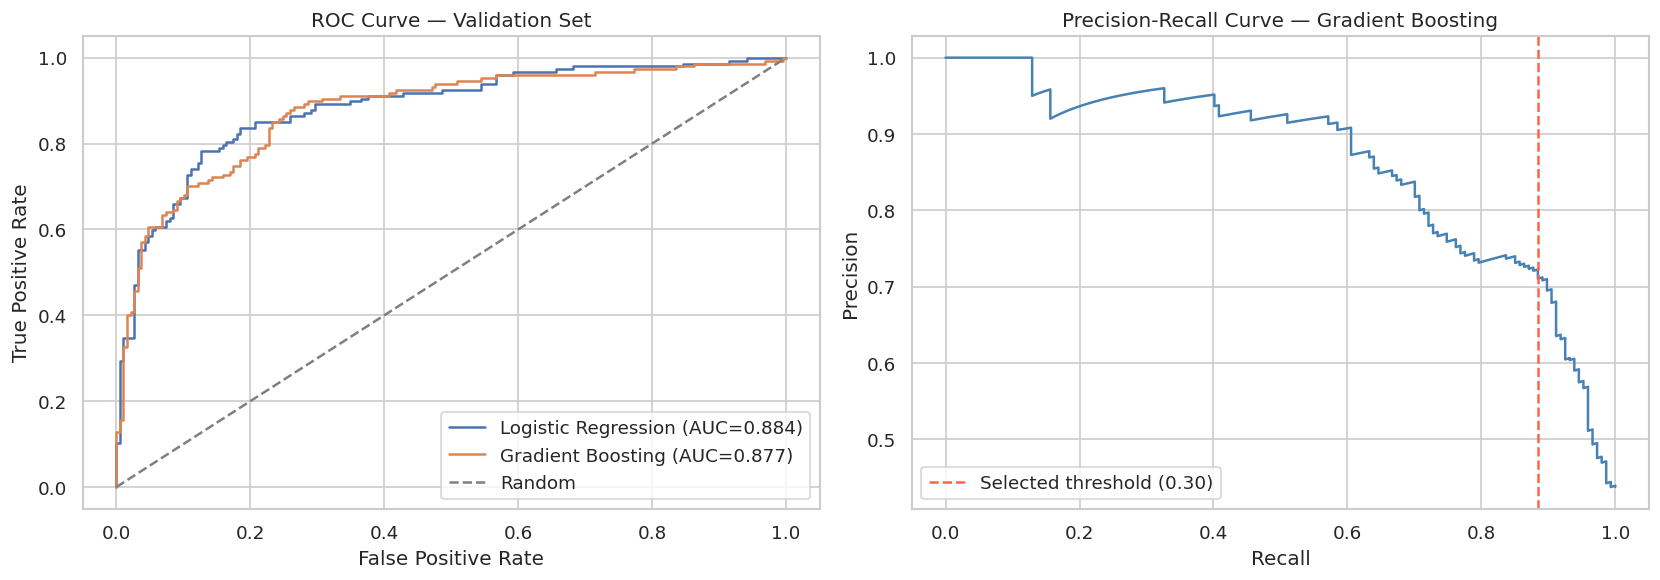

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr_lr, tpr_lr, _ = roc_curve(y_val, lr_proba)
fpr_gb, tpr_gb, _ = roc_curve(y_val, gb_proba_val)
axes[0].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_val, lr_proba):.3f})')
axes[0].plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC={roc_auc_score(y_val, gb_proba_val):.3f})')
axes[0].plot([0,1],[0,1],'--', color='gray', label='Random')
axes[0].set_title('ROC Curve — Validation Set')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

axes[1].plot(recalls, precisions, color='steelblue')
axes[1].axvline(x=recall_score(y_val, gb_pred_val), color='tomato', linestyle='--',
                label=f'Selected threshold ({best_thresh:.2f})')
axes[1].set_title('Precision-Recall Curve — Gradient Boosting')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.savefig('charts/fig1_roc_pr_curves.png', bbox_inches='tight')
plt.show()

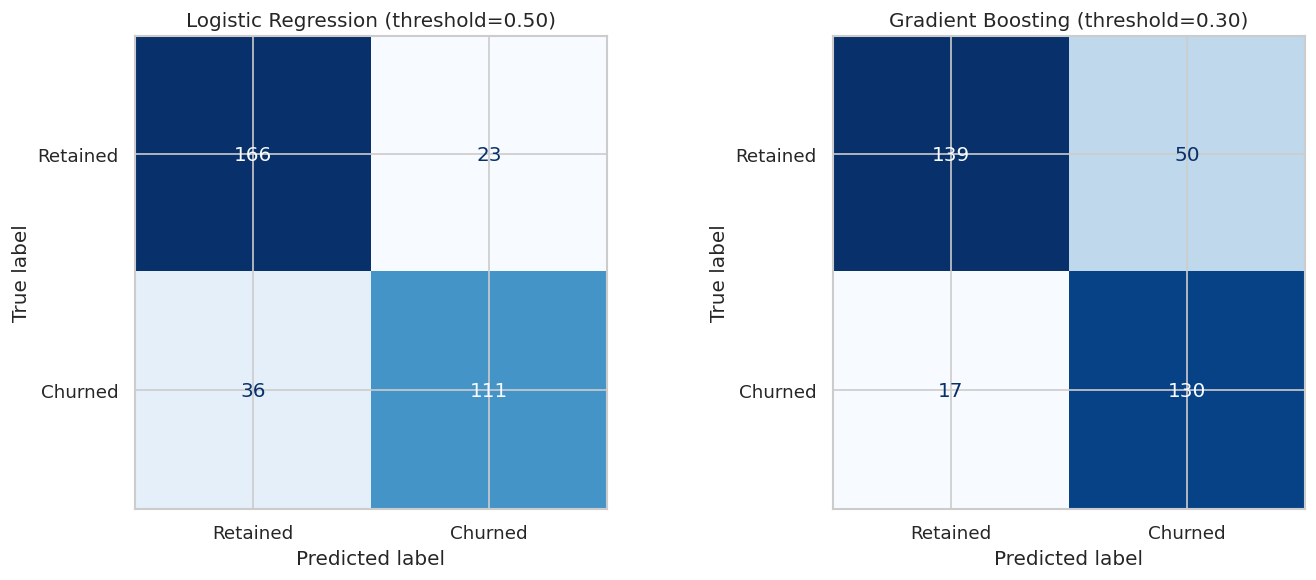

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, title in zip(axes,
    [lr_pred, gb_pred_val],
    ['Logistic Regression (threshold=0.50)', f'Gradient Boosting (threshold={best_thresh:.2f})']):
    cm = confusion_matrix(y_val, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Retained','Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('charts/fig2_confusion_matrix.png', bbox_inches='tight')
plt.show()

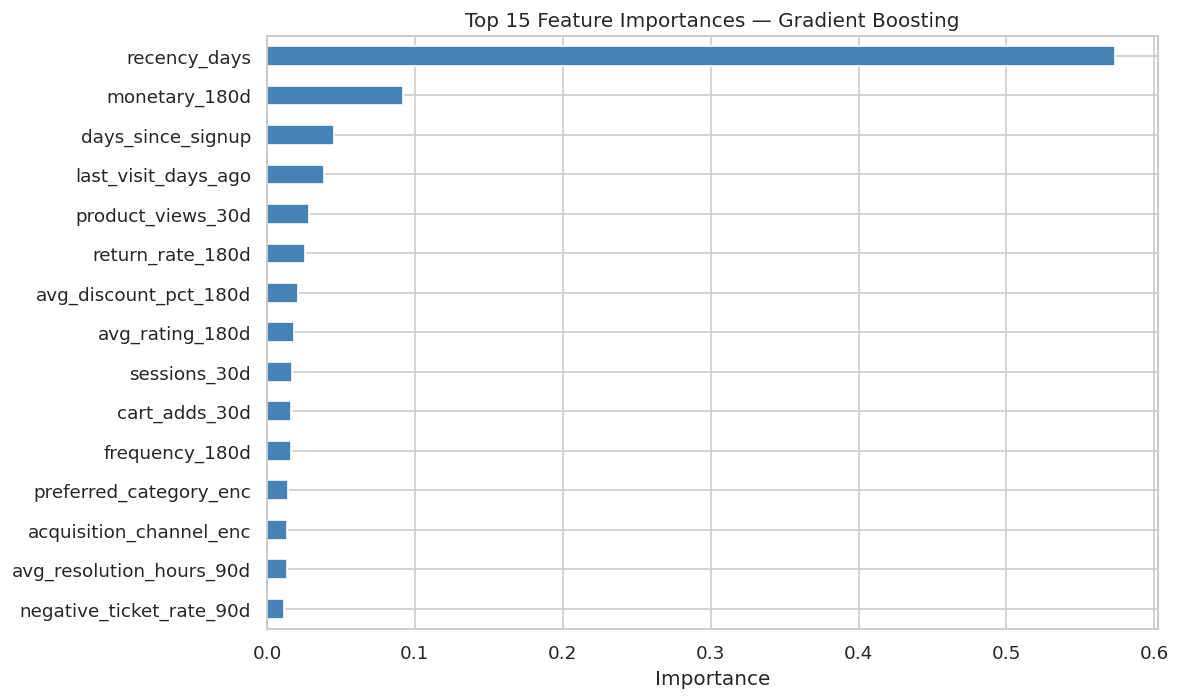

recency_days                0.5737
monetary_180d               0.0918
days_since_signup           0.0457
last_visit_days_ago         0.0387
product_views_30d           0.0283
return_rate_180d            0.0259
avg_discount_pct_180d       0.0209
avg_rating_180d             0.0185
sessions_30d                0.0167
cart_adds_30d               0.0166
frequency_180d              0.0163
preferred_category_enc      0.0144
acquisition_channel_enc     0.0138
avg_resolution_hours_90d    0.0134
negative_ticket_rate_90d    0.0118


In [14]:
fi = pd.Series(gb.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
fi.plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Top 15 Feature Importances — Gradient Boosting')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('charts/fig3_feature_importance.png', bbox_inches='tight')
plt.show()
print(fi.round(4).to_string())

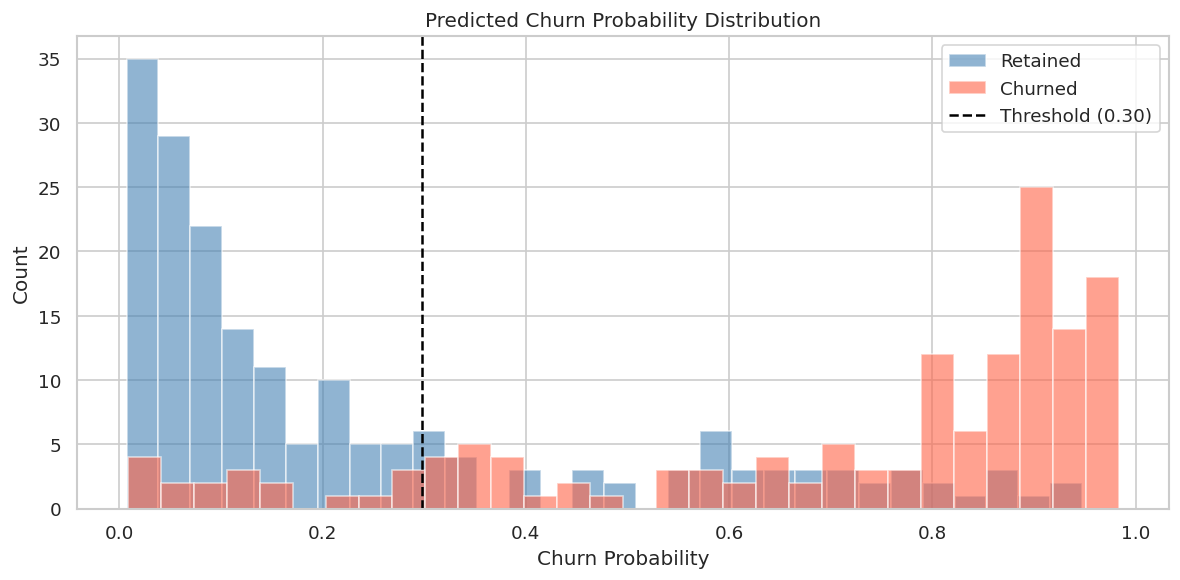

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(gb_proba_val[y_val==0], bins=30, alpha=0.6, label='Retained', color='steelblue')
ax.hist(gb_proba_val[y_val==1], bins=30, alpha=0.6, label='Churned', color='tomato')
ax.axvline(x=best_thresh, color='black', linestyle='--', label=f'Threshold ({best_thresh:.2f})')
ax.set_title('Predicted Churn Probability Distribution')
ax.set_xlabel('Churn Probability')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('charts/fig4_probability_distribution.png', bbox_inches='tight')
plt.show()

## 9. Final Evaluation on Test Set

In [16]:
gb_proba_test = gb.predict_proba(X_test)[:,1]
gb_pred_test  = (gb_proba_test >= best_thresh).astype(int)

test_auc  = round(float(roc_auc_score(y_test, gb_proba_test)), 4)
test_f1   = round(float(f1_score(y_test, gb_pred_test)), 4)
test_prec = round(float(precision_score(y_test, gb_pred_test)), 4)
test_rec  = round(float(recall_score(y_test, gb_pred_test)), 4)
test_acc  = round(float(accuracy_score(y_test, gb_pred_test)), 4)
test_cm   = confusion_matrix(y_test, gb_pred_test).tolist()

print('Gradient Boosting — Test Set (Final)')
print(f'  AUC-ROC  : {test_auc}')
print(f'  F1 Score : {test_f1}')
print(f'  Precision: {test_prec}')
print(f'  Recall   : {test_rec}')
print(f'  Accuracy : {test_acc}')
print(f'  Confusion: {test_cm}')
print(f'  Threshold: {round(best_thresh, 4)}')

metrics = {
    'model': 'GradientBoostingClassifier',
    'split': 'test',
    'threshold': round(best_thresh, 4),
    'roc_auc': test_auc,
    'f1_score': test_f1,
    'precision': test_prec,
    'recall': test_rec,
    'accuracy': test_acc,
    'confusion_matrix': {'tn': test_cm[0][0], 'fp': test_cm[0][1],
                         'fn': test_cm[1][0], 'tp': test_cm[1][1]},
    'baseline_lr_val_auc': 0.8845,
    'baseline_lr_val_f1': 0.79
}
with open('metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('metrics.json saved')

Gradient Boosting — Test Set (Final)
  AUC-ROC  : 0.8646
  F1 Score : 0.8043
  Precision: 0.7317
  Recall   : 0.8929
  Accuracy : 0.7827
  Confusion: [[113, 55], [18, 150]]
  Threshold: 0.2977
metrics.json saved


## 10. Save Model

In [17]:
model_artifact = {
    'model': gb,
    'encoders': encoders,
    'features': feature_cols,
    'threshold': best_thresh,
    'num_cols': num_cols,
    'cat_cols': cat_cols
}
with open('model.pkl', 'wb') as f:
    pickle.dump(model_artifact, f)
print('model.pkl saved')

with open('model.pkl', 'rb') as f:
    loaded = pickle.load(f)
test_pred_verify = loaded['model'].predict_proba(X_test)[:,1]
print('Model load verified. AUC:', round(float(roc_auc_score(y_test, test_pred_verify)), 4))

model.pkl saved
Model load verified. AUC: 0.8646


## 11. Error Analysis Preview

In [18]:
val_res = val[['customer_id','churn_next_60d'] + num_cols[:5]].copy()
val_res['churn_proba'] = gb_proba_val
val_res['predicted']   = gb_pred_val

fp_cases = val_res[(val_res['predicted']==1) & (val_res['churn_next_60d']==0)].head(5)
fn_cases = val_res[(val_res['predicted']==0) & (val_res['churn_next_60d']==1)].head(5)

print('False Positives (predicted churn, actually retained):')
print(fp_cases[['customer_id','churn_proba','recency_days','frequency_180d','monetary_180d']].to_string())

print('\nFalse Negatives (predicted retained, actually churned):')
print(fn_cases[['customer_id','churn_proba','recency_days','frequency_180d','monetary_180d']].to_string())

False Positives (predicted churn, actually retained):
    customer_id  churn_proba  recency_days  frequency_180d  monetary_180d
26    CUST00027     0.461213            70               1        2128.34
99    CUST00100     0.616108            70               1         372.37
143   CUST00144     0.554832            86               2         928.58
164   CUST00165     0.792368           103               3        1825.77
176   CUST00177     0.636742            82               1         255.04

False Negatives (predicted retained, actually churned):
    customer_id  churn_proba  recency_days  frequency_180d  monetary_180d
144   CUST00145     0.278905            30               1         502.35
156   CUST00157     0.046049             0               1         376.83
187   CUST00188     0.056525            29               2        1880.31
326   CUST00327     0.118450             2               1         367.29
336   CUST00337     0.090449             7               2        1887.73
